In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense
from sklearn.metrics import classification_report, accuracy_score

In [3]:
np.random.seed(42)
tf.random.set_seed(42)

In [4]:
vocab_size = 10000

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples: 25000
Testing samples: 25000


In [5]:
max_length = 200

X_train = pad_sequences(X_train, maxlen=max_length)
X_test = pad_sequences(X_test, maxlen=max_length)

print("Training shape:", X_train.shape)

Training shape: (25000, 200)


In [6]:
rnn_model = Sequential()

rnn_model.add(Embedding(vocab_size, 128, input_length=max_length))
rnn_model.add(SimpleRNN(64))
rnn_model.add(Dense(1, activation='sigmoid'))

rnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [7]:
history_rnn = rnn_model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 31s 90ms/step - accuracy: 0.6544 - loss: 0.6030 - val_accuracy: 0.7534 - val_loss: 0.5051
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 42s 94ms/step - accuracy: 0.8061 - loss: 0.4328 - val_accuracy: 0.8088 - val_loss: 0.4828
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 40s 91ms/step - accuracy: 0.8865 - loss: 0.2730 - val_accuracy: 0.6140 - val_loss: 0.6534
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 29s 93ms/step - accuracy: 0.8188 - loss: 0.3960 - val_accuracy: 0.7758 - val_loss: 0.6020
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 40s 90ms/step - accuracy: 0.9696 - loss: 0.0952 - val_accuracy: 0.7260 - val_loss: 0.8039


In [9]:
lstm_model = Sequential()

lstm_model.add(Embedding(vocab_size, 128, input_length=max_length))
lstm_model.add(LSTM(64))
lstm_model.add(Dense(1, activation='sigmoid'))

lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:
history_lstm = lstm_model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 90s 280ms/step - accuracy: 0.8038 - loss: 0.4152 - val_accuracy: 0.8668 - val_loss: 0.3192
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 81s 260ms/step - accuracy: 0.8704 - loss: 0.3074 - val_accuracy: 0.8638 - val_loss: 0.3268
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 82s 263ms/step - accuracy: 0.9143 - loss: 0.2199 - val_accuracy: 0.8606 - val_loss: 0.3534
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 142s 262ms/step - accuracy: 0.9333 - loss: 0.1816 - val_accuracy: 0.8412 - val_loss: 0.3768
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 83s 264ms/step - accuracy: 0.9422 - loss: 0.1550 - val_accuracy: 0.8418 - val_loss: 0.4036


In [11]:
rnn_pred = (rnn_model.predict(X_test) > 0.5).astype("int32")
lstm_pred = (lstm_model.predict(X_test) > 0.5).astype("int32")

print("RNN Accuracy:", accuracy_score(y_test, rnn_pred))
print("LSTM Accuracy:", accuracy_score(y_test, lstm_pred))

782/782 ━━━━━━━━━━━━━━━━━━━━ 19s 23ms/step
782/782 ━━━━━━━━━━━━━━━━━━━━ 37s 47ms/step
RNN Accuracy: 0.7234
LSTM Accuracy: 0.84396


In [12]:
print("RNN Report")
print(classification_report(y_test, rnn_pred))

print("LSTM Report")
print(classification_report(y_test, lstm_pred))

RNN Report
              precision    recall  f1-score   support

           0       0.69      0.80      0.74     12500
           1       0.76      0.65      0.70     12500

    accuracy                           0.72     25000
   macro avg       0.73      0.72      0.72     25000
weighted avg       0.73      0.72      0.72     25000

LSTM Report
              precision    recall  f1-score   support

           0       0.86      0.83      0.84     12500
           1       0.83      0.86      0.85     12500

    accuracy                           0.84     25000
   macro avg       0.84      0.84      0.84     25000
weighted avg       0.84      0.84      0.84     25000



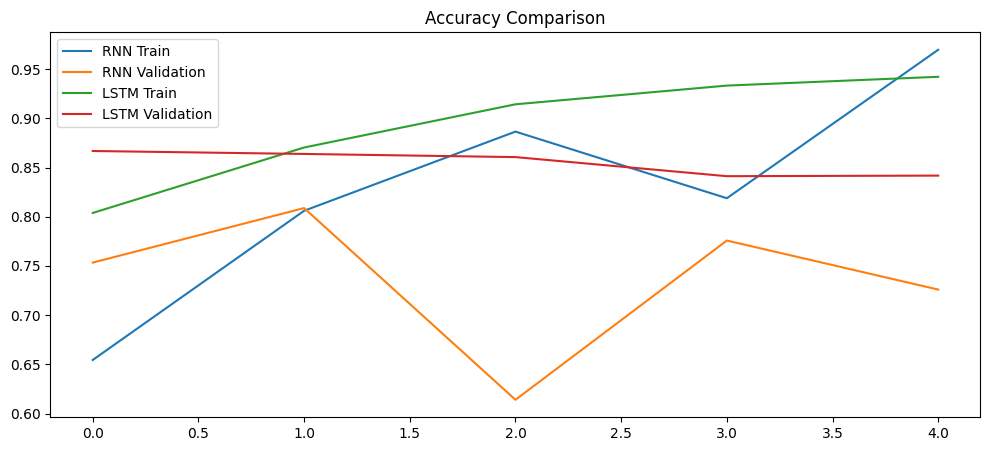

In [13]:
plt.figure(figsize=(12,5))

plt.plot(history_rnn.history['accuracy'], label='RNN Train')
plt.plot(history_rnn.history['val_accuracy'], label='RNN Validation')

plt.plot(history_lstm.history['accuracy'], label='LSTM Train')
plt.plot(history_lstm.history['val_accuracy'], label='LSTM Validation')

plt.legend()
plt.title("Accuracy Comparison")
plt.show()

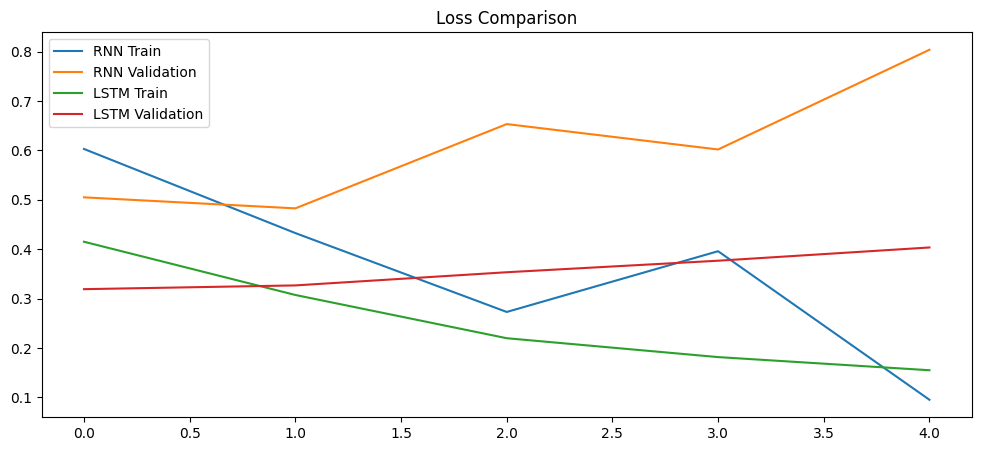

In [14]:
plt.figure(figsize=(12,5))

plt.plot(history_rnn.history['loss'], label='RNN Train')
plt.plot(history_rnn.history['val_loss'], label='RNN Validation')

plt.plot(history_lstm.history['loss'], label='LSTM Train')
plt.plot(history_lstm.history['val_loss'], label='LSTM Validation')

plt.legend()
plt.title("Loss Comparison")
plt.show()

In [15]:
from tensorflow.keras.layers import GRU

In [16]:
gru_model = Sequential()

gru_model.add(Embedding(vocab_size, 128, input_length=max_length))
gru_model.add(GRU(64))
gru_model.add(Dense(1, activation='sigmoid'))

gru_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

gru_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [17]:
history_gru = gru_model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 94s 287ms/step - accuracy: 0.7562 - loss: 0.4845 - val_accuracy: 0.8456 - val_loss: 0.3623
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 89s 284ms/step - accuracy: 0.8930 - loss: 0.2627 - val_accuracy: 0.8554 - val_loss: 0.3600
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 142s 285ms/step - accuracy: 0.9196 - loss: 0.2091 - val_accuracy: 0.8432 - val_loss: 0.3556
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 148s 303ms/step - accuracy: 0.9448 - loss: 0.1502 - val_accuracy: 0.8452 - val_loss: 0.3767
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 89s 284ms/step - accuracy: 0.9607 - loss: 0.1104 - val_accuracy: 0.8660 - val_loss: 0.4044


In [18]:
gru_pred = (gru_model.predict(X_test) > 0.5).astype("int32")

print("GRU Accuracy:", accuracy_score(y_test, gru_pred))

782/782 ━━━━━━━━━━━━━━━━━━━━ 31s 39ms/step
GRU Accuracy: 0.85632


In [19]:
print("GRU Report")
print(classification_report(y_test, gru_pred))

GRU Report
              precision    recall  f1-score   support

           0       0.83      0.90      0.86     12500
           1       0.89      0.82      0.85     12500

    accuracy                           0.86     25000
   macro avg       0.86      0.86      0.86     25000
weighted avg       0.86      0.86      0.86     25000



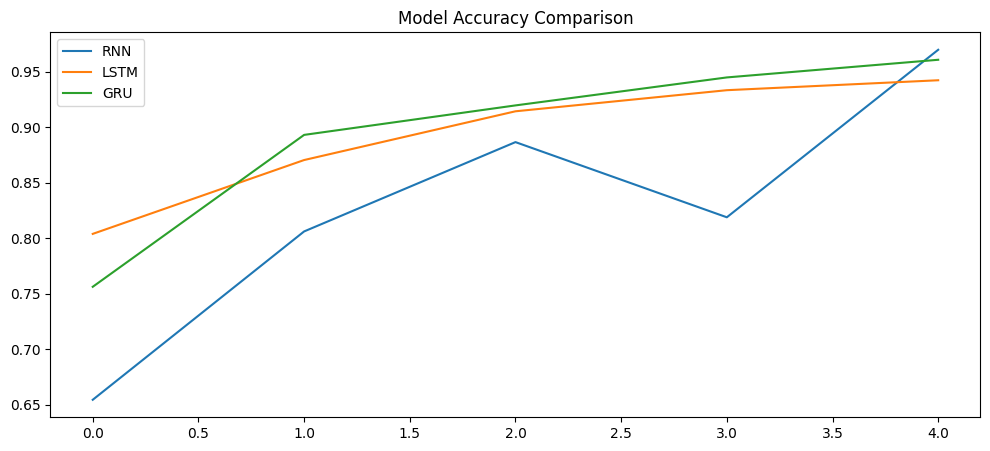

In [20]:
plt.figure(figsize=(12,5))

plt.plot(history_rnn.history['accuracy'], label='RNN')
plt.plot(history_lstm.history['accuracy'], label='LSTM')
plt.plot(history_gru.history['accuracy'], label='GRU')

plt.legend()
plt.title("Model Accuracy Comparison")
plt.show()

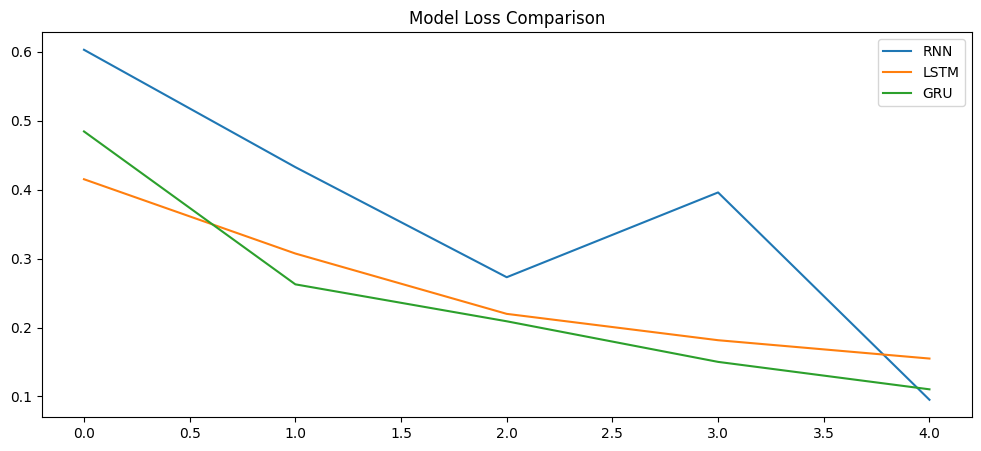

In [21]:
plt.figure(figsize=(12,5))

plt.plot(history_rnn.history['loss'], label='RNN')
plt.plot(history_lstm.history['loss'], label='LSTM')
plt.plot(history_gru.history['loss'], label='GRU')

plt.legend()
plt.title("Model Loss Comparison")
plt.show()